# POF 2017-2018 — Education and Household Debt

**TCC — Universidade de São Paulo**

This notebook is intentionally *thin*: it only **imports and calls** the `pof`
package (`src/pof/`). All reading, aggregation, debt construction, modelling and
plotting logic lives in the package. No transformation logic is defined here.

**Pipeline**
1. Configure the run (`AnalysisConfig`) — education measure, member filters, **debt codes** and **UC filters** are all parameters
2. Load the POF tables (`PofReader`)
3. Check join integrity via RENDA_TOTAL (`JoinIntegrityChecker`)
4. Build the UC-level analytical dataset (`AnalyticalDataset`)
5. Descriptive analysis + figures (`DescriptivePlots`)
6. Econometric models (`DebtModels`)
7. Per-code debt-vs-education direction (`PerCodeAnalysis`)

See `docs/` for the project goal, dictionary/CSV findings, current-state review and architecture.

## 1. Setup & configuration

In [ ]:
import sys
from pathlib import Path
SRC = Path("src").resolve()
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, polars as pl, matplotlib.pyplot as plt

from pof import default_config, DEBT_CATEGORIES
from pof.io import PofReader
from pof.integrity import JoinIntegrityChecker
from pof.dataset import AnalyticalDataset
from pof.plots import DescriptivePlots
from pof.models import DebtModels
from pof.code_analysis import PerCodeAnalysis, write_reports

config = default_config()

# === PARAMETERS you can change ============================================
# -- Education measure --
# education_variable : "ANOS_ESTUDO" (years 0-16) or "NIVEL_INSTRUCAO" (level 1-7)
# education_method   : "mean" | "median" | "mode" | "min" | "max"
config.education_variable = "NIVEL_INSTRUCAO"
config.education_method   = "median"

# -- Which household MEMBERS feed the education aggregation --
config.filter_adults      = True    # keep only people aged >= 18 (V0403)
config.filter_with_income = True    # keep only people who had income/work (V0407==1)

# -- Which DEBT CODES count as "debt" (headline analysis) --
# Focus on personal-loan costs (block 48 "EMPRESTIMO" codes). This is the one debt
# category higher for LOWER-education households. Set to None to evaluate all codes.
config.debt_codes_override = ["4800101", "4800102", "4800201", "4800301"]

# -- Which UCs to keep in the analytical sample --
config.keep_only_with_income = True   # drop UCs with RENDA_TOTAL <= 0 (ratio undefined)
config.keep_only_with_debt   = False  # False => use full population (all UCs)

config.ensure_dirs()
print("education:", config.education_variable, "/", config.education_method)
print("member filters: adults =", config.filter_adults, "| with income =", config.filter_with_income)
print("UC filters: only-with-income =", config.keep_only_with_income,
      "| only-with-debt =", config.keep_only_with_debt)
print("debt codes in use:", config.effective_debt_codes())

education: ANOS_ESTUDO / mean
member filters: adults = True | with income = True
UC filters: only-with-income = True | only-with-debt = False
debt codes in use: ['4800101', '4800102', '4800201', '4800301']


## 2. Load the POF tables

In [2]:
reader = PofReader(config)
tables = reader.load_all()
{name: df.shape for name, df in tables.items()}

[MORADOR] read from parquet cache -> (178431, 56)
[DESPESA_INDIVIDUAL] read from parquet cache -> (1836032, 25)
[DESPESA_COLETIVA] read from parquet cache -> (478572, 27)


{'MORADOR': (178431, 56),
 'DESPESA_INDIVIDUAL': (1836032, 25),
 'DESPESA_COLETIVA': (478572, 27)}

## 3. Join-integrity check (RENDA_TOTAL)

RENDA_TOTAL is the **UC monthly total**, identical across the three sources and
constant within each UC (it is NOT the person's income in DESPESA_INDIVIDUAL —
just repeated per row, so summing it would double-count). This check verifies the
UC join keys line up.

In [3]:
report = JoinIntegrityChecker(config).check_and_report(
    tables, save_to=config.outputs_dir / "integrity_report.txt"
)
assert report.passed, "Join integrity failed — see report above."
print("\nJoin integrity OK.")

RENDA_TOTAL / join-key integrity report
  [PASS] MORADOR: RENDA_TOTAL constant within each UC
  [PASS] DESPESA_INDIVIDUAL: RENDA_TOTAL constant within each UC
  [PASS] DESPESA_COLETIVA: RENDA_TOTAL constant within each UC
  [PASS] RENDA_TOTAL agrees MORADOR vs DESPESA_INDIVIDUAL
  [PASS] RENDA_TOTAL agrees MORADOR vs DESPESA_COLETIVA
  [PASS] every DESPESA_INDIVIDUAL UC exists in MORADOR
  [PASS] every DESPESA_COLETIVA UC exists in MORADOR

  - MORADOR: UCs where RENDA_TOTAL varies within UC: 0
  - DESPESA_INDIVIDUAL: UCs where RENDA_TOTAL varies within UC: 0
  - DESPESA_COLETIVA: UCs where RENDA_TOTAL varies within UC: 0
  - UCs shared by all 3 sources: 57861
  - mismatches MORADOR vs DESPESA_INDIVIDUAL: 0
  - mismatches MORADOR vs DESPESA_COLETIVA: 0
  - orphan UCs in DESPESA_INDIVIDUAL (not in MORADOR): 0
  - orphan UCs in DESPESA_COLETIVA (not in MORADOR): 0
  - correct sum of per-UC income (MORADOR, R$): 271057726.75
  - NAIVE row-sum of RENDA_TOTAL in DESPESA_INDIVIDUAL (R$, doub

## 4. Build the analytical dataset (one row per UC)

Population-weighted schooling/age (configured variable + method + member filters),
**deflated + annualized** debt per UC from the configured codes, then derived
`debt_to_income`, `has_debt`, `log_debt`, etc., honouring the UC filters.

In [4]:
dataset = AnalyticalDataset(config)
df = dataset.build(tables)
pdf = df.to_pandas()

print(f"UCs: {df.height:,}")
print(f"Weighted households: {df.select(pl.col('weight').sum()).item():,.0f}")
print(f"UCs with debt: {int(pdf['has_debt'].sum()):,} ({pdf['has_debt'].mean()*100:.1f}%)")
df.head()

UCs: 57,965
Weighted households: 68,941,658
UCs with debt: 12,227 (21.1%)


COD_UPA,NUM_DOM,NUM_UC,UF,n_members_aggregated,education_min,education_max,education_mean,education_median,education_mode,age_mean,age_median,head_sex,household_income,weight,education,total_debt,debt_personal_loan,debt_interest_and_fees,debt_principal_repayment,debt_default_charges,debt_late_payment_penalties,debt_to_income,has_debt,log_debt,log_income,head_is_woman,education_band
str,str,str,str,u32,i64,i64,i64,i64,i64,i64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,i8,f64,f64,i8,cat
"""130048174""","""2""","""1""","""13""",3,0,12,8,12,12,59,75,"""2""",1802.38,1076.729278,8,987.63,987.63,0.0,0.0,0.0,0.0,0.547959,1,6.895308,7.496863,1,"""Lower secondary (4-8)"""
"""420002560""","""12""","""1""","""42""",2,5,5,5,5,5,39,38,"""1""",7381.07,1085.36955,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,null,8.906674,0,"""Lower secondary (4-8)"""
"""140007288""","""9""","""1""","""14""",1,12,12,12,12,12,33,33,"""1""",897.76,126.19117,12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,null,6.799903,0,"""Higher education (11+)"""
"""510057558""","""10""","""1""","""51""",1,12,12,12,12,12,30,30,"""1""",1620.58,145.333181,12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,null,7.390539,0,"""Higher education (11+)"""
"""280030460""","""6""","""1""","""28""",1,12,12,12,12,12,21,21,"""2""",1878.65,298.084431,12,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,null,7.538309,1,"""Higher education (11+)"""


### 4.1 Sanity checks

In [5]:
checks = {
    "weighted_households": float(np.sum(pdf["weight"])),
    "median_income_R$": float(pdf["household_income"].median()),
    "mean_income_R$": float(pdf["household_income"].mean()),
    "share_with_debt_%": float(pdf["has_debt"].mean() * 100),
    "median_annual_debt_debtors_R$": float(pdf.loc[pdf.has_debt == 1, "total_debt"].median()),
}
pd.Series(checks).round(2)

weighted_households              68941657.61
median_income_R$                     2925.09
mean_income_R$                       4674.97
share_with_debt_%                      21.09
median_annual_debt_debtors_R$         349.43
dtype: float64

## 5. Descriptive analysis (population-weighted)

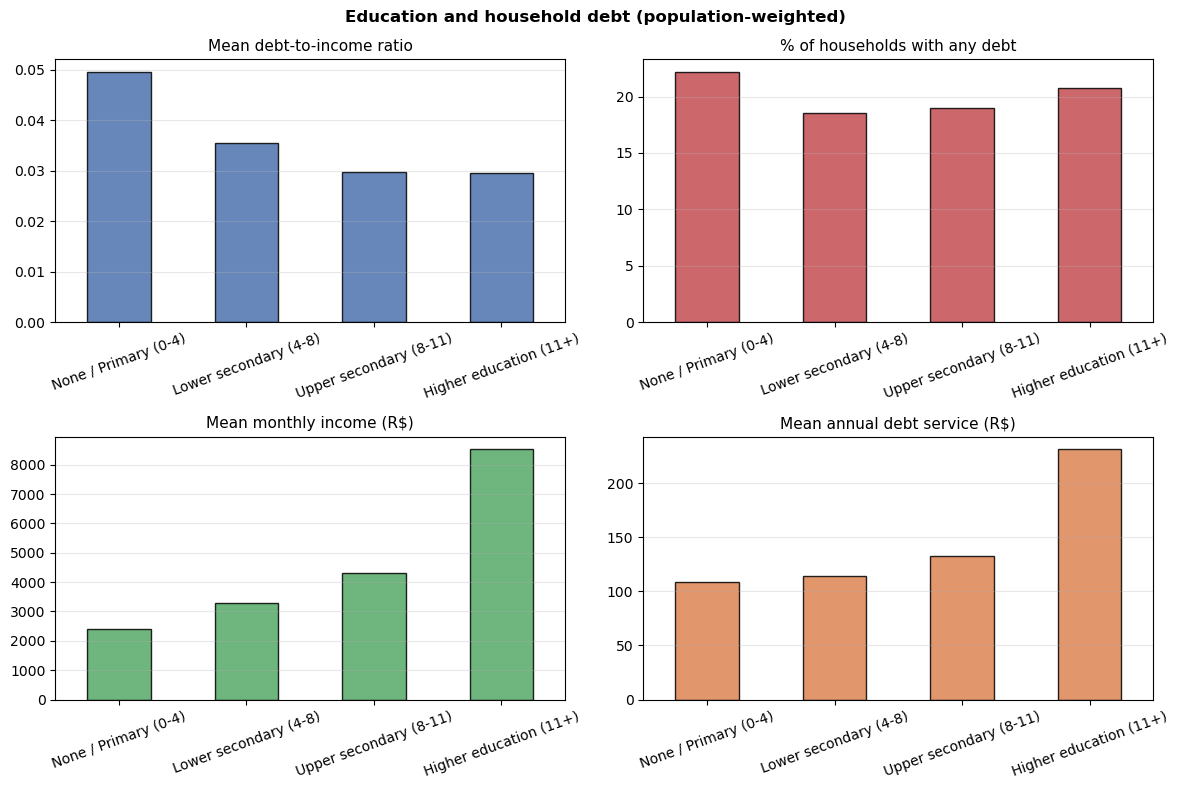

In [6]:
plots = DescriptivePlots(config)
plots.debt_burden_by_education(pdf); plt.show()

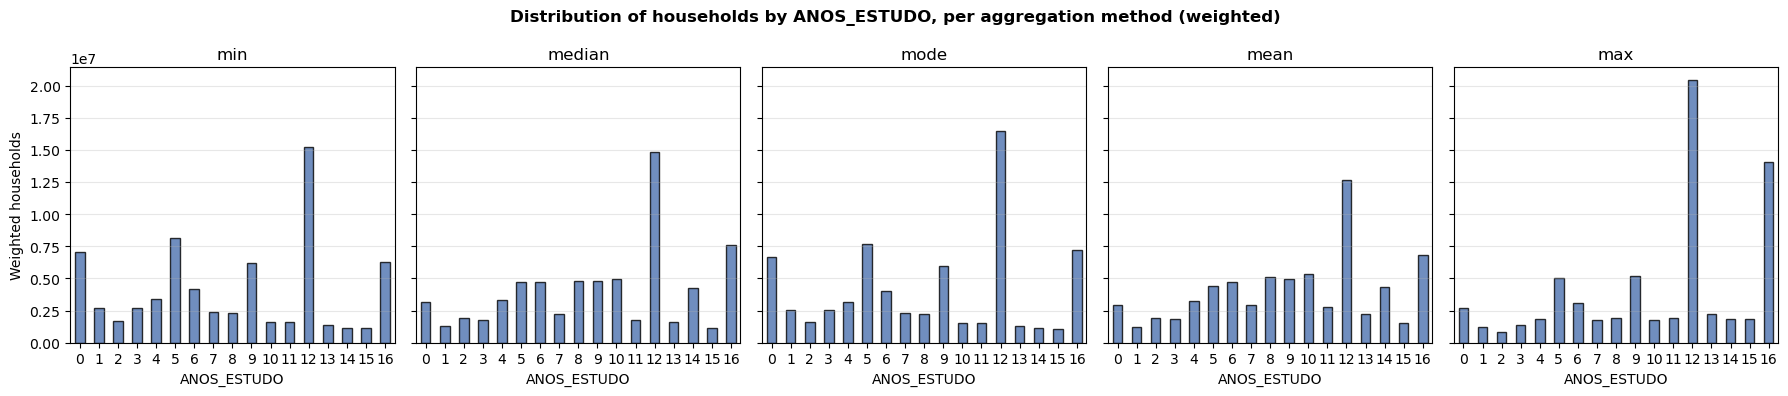

In [7]:
plots.education_distribution(pdf); plt.show()

In [14]:
# always shows all debt categories defined in DEBT_CATEGORIES
# plots.debt_by_category(pdf); plt.show()

### 5.1 Weighted summary by education band

In [9]:
def wmean(s, w):
    m = s.notna() & w.notna() & (w > 0)
    return np.average(s[m], weights=w[m]) if m.any() else np.nan

rows = []
for band in config.education_band_spec()[1]:
    sub = pdf[pdf["education_band"] == band]
    if len(sub) == 0: continue
    rows.append({
        "education_band": band, "n_ucs": len(sub),
        "mean_income": wmean(sub["household_income"], sub["weight"]),
        "share_with_debt_%": wmean(sub["has_debt"], sub["weight"]) * 100,
        "mean_debt_to_income": wmean(sub["debt_to_income"], sub["weight"]),
    })
pd.DataFrame(rows).round(4)

,education_band,n_ucs,mean_income,share_with_debt_%,mean_debt_to_income
0,None / Primary (0-4),11638,2410.7336,22.1925,0.0496
1,Lower secondary (4-8),15699,3283.1303,18.5260,0.0355
2,Upper secondary (8-11),10726,4304.1664,18.9914,0.0298
3,Higher education (11+),19902,8523.9596,20.7218,0.0295


## 5.2 Interactive Plotly Figures with Statistical Tests

This section produces publication-ready figures with Portuguese labels and statistical
significance indicators. All figures are saved as interactive HTML files in `figures/`.

**Important:** Code is in English; figure text (axes, legends, titles) is in Portuguese.
This distinction is documented in `docs/04_architecture.md`.

In [ ]:
from pof.plots_plotly import DescriptivePlotsPlotly

plotly_figs = DescriptivePlotsPlotly(config)

### 5.2.1 Income by education band

In [ ]:
fig_income = plotly_figs.income_by_education(pdf, save=True, show_stats=True)
fig_income.show()

### 5.2.2 Debt spending by education band (all UCs)

In [ ]:
fig_debt = plotly_figs.debt_spending_by_education(pdf, save=True)
fig_debt.show()

### 5.2.3 Debt-to-income ratio by education band (all UCs)

In [ ]:
fig_burden = plotly_figs.debt_burden_by_education(pdf, save=True, show_stats=True)
fig_burden.show()

### 5.2.4 Debt prevalence by education band (%)

In [ ]:
fig_prev = plotly_figs.debt_prevalence_by_education(pdf, save=True, show_stats=True)
fig_prev.show()

### 5.2.5 Debt distribution among debtors only

In [ ]:
fig_debtors = plotly_figs.debt_distribution_debtors_only(pdf, save=True, show_stats=True)
fig_debtors.show()

### 5.2.6 Income vs debt scatter plot (colored by education)

In [ ]:
fig_scatter = plotly_figs.income_debt_scatter_by_education(pdf, save=True)
fig_scatter.show()

### 5.2.7 Debt-to-income ratio distribution (box plots)

In [ ]:
fig_distribution = plotly_figs.debt_ratio_distribution_by_education(pdf, save=True)
fig_distribution.show()

### 5.2.8 Comprehensive dashboard (4-panel)

In [ ]:
fig_dashboard = plotly_figs.comprehensive_dashboard(pdf, save=True)
fig_dashboard.show()

### 5.2.9 Summary statistics table with p-values

In [ ]:
summary_stats = plotly_figs.summary_statistics_table(pdf, save=True)
summary_stats.round(4)

## 5.2 Interactive Plotly Figures with Statistical Tests

This section produces publication-ready figures with Portuguese labels and statistical
significance indicators. All figures are saved as interactive HTML files in `figures/`.

**Important:** Code is in English; figure text (axes, legends, titles) is in Portuguese.
This distinction is documented in `docs/04_architecture.md`.

In [ ]:
from pof.plots_plotly import DescriptivePlotsPlotly

plotly_figs = DescriptivePlotsPlotly(config)

### 5.2.1 Income by education band

In [ ]:
fig_income = plotly_figs.income_by_education(pdf, save=True, show_stats=True)
fig_income.show()

### 5.2.2 Debt spending by education band (all UCs)

In [ ]:
fig_debt = plotly_figs.debt_spending_by_education(pdf, save=True)
fig_debt.show()

### 5.2.3 Debt-to-income ratio by education band (all UCs)

In [ ]:
fig_burden = plotly_figs.debt_burden_by_education(pdf, save=True, show_stats=True)
fig_burden.show()

### 5.2.4 Debt prevalence by education band (%)

In [ ]:
fig_prev = plotly_figs.debt_prevalence_by_education(pdf, save=True, show_stats=True)
fig_prev.show()

### 5.2.5 Debt distribution among debtors only

In [ ]:
fig_debtors = plotly_figs.debt_distribution_debtors_only(pdf, save=True, show_stats=True)
fig_debtors.show()

### 5.2.6 Income vs debt scatter plot (colored by education)

In [ ]:
fig_scatter = plotly_figs.income_debt_scatter_by_education(pdf, save=True)
fig_scatter.show()

### 5.2.7 Debt-to-income ratio distribution (box plots)

In [ ]:
fig_distribution = plotly_figs.debt_ratio_distribution_by_education(pdf, save=True)
fig_distribution.show()

### 5.2.8 Comprehensive dashboard (4-panel)

In [ ]:
fig_dashboard = plotly_figs.comprehensive_dashboard(pdf, save=True)
fig_dashboard.show()

### 5.2.9 Summary statistics table with p-values

In [ ]:
summary_stats = plotly_figs.summary_statistics_table(pdf, save=True)
summary_stats.round(4)

## 6. Econometric models

Two-part (hurdle) + relative-burden regressions, **population-weighted**, HC3
errors for the OLS parts. Focal term = `education` (the configured measure).

In [10]:
models = DebtModels(config)
results_df = DebtModels.to_frame(models.fit_all(pdf))
results_df.to_csv(config.outputs_dir / "model_summary.csv", index=False)
results_df

,model,focal_term,coef,std_err,p_value,nobs,odds_ratio,rsquared
0,logit_access,education,-0.021312,0.000097,0.000000,57965,0.978914,NaN
1,ols_log_volume,education,0.012669,0.003881,0.001098,12227,NaN,0.202911
2,ols_burden,education,-0.000044,0.000120,0.717089,57965,NaN,0.020389


## 7. Per-code analysis — which debts are higher for LOWER education?

For **every** candidate debt code (active or commented-out), the weighted-OLS
slope of that code's debt/income vs education. Negative slope = relatively higher
for lower-education households. Run for both education variables; sorted CSV +
Markdown written to `outputs/`.

In [11]:
def run_per_code(var, method):
    cfg = default_config()
    cfg.education_variable, cfg.education_method = var, method
    cfg.filter_adults = config.filter_adults
    cfg.filter_with_income = config.filter_with_income
    cfg.keep_only_with_income = config.keep_only_with_income
    cfg.ensure_dirs()
    uc = AnalyticalDataset(cfg).build(tables)
    res = PerCodeAnalysis(cfg).run(uc, tables["DESPESA_INDIVIDUAL"], tables["DESPESA_COLETIVA"])
    paths = write_reports(res, cfg, var)
    print(f"[{var}/{method}] wrote {paths['csv'].name} and {paths['md'].name}")
    return res

res_years = run_per_code("ANOS_ESTUDO", "mean")
res_level = run_per_code("NIVEL_INSTRUCAO", "mode")
res_years[["code","label","category","active","n_ucs_with_spend",
           "slope_vs_education","slope_p_value","direction"]]

[ANOS_ESTUDO/mean] wrote debt_by_code_vs_anos_estudo.csv and debt_by_code_vs_anos_estudo.md
[NIVEL_INSTRUCAO/mode] wrote debt_by_code_vs_nivel_instrucao.csv and debt_by_code_vs_nivel_instrucao.md


,code,label,category,active,n_ucs_with_spend,slope_vs_education,slope_p_value,direction
0,4800101,PAGAMENTO DE EMPRESTIMO (loan repayment),personal_loan,True,12061,-1.476277e-03,1.725958e-15,lower with education
1,2601103,RENOVACAO DE CHEQUE ESPECIAL (overdraft renewal),interest_and_fees,False,1,-6.801950e-06,6.330628e-01,flat / not significant
2,4800201,JUROS DE EMPRESTIMO (loan interest),personal_loan,True,669,-6.366257e-06,7.038463e-01,flat / not significant
3,1000201,ADICIONAIS DO ALUGUEL (rent surcharges),late_payment_penalties,True,50,-1.915879e-06,7.773067e-01,flat / not significant
4,1203301,JUROS E MULTA DE CONTA DE AGUA (water-bill lat...,late_payment_penalties,True,6,-1.287869e-06,4.246257e-01,flat / not significant
5,1203201,JUROS E MULTA DE ENERGIA ELETRICA (electricity...,late_payment_penalties,True,42,-6.172524e-07,4.698960e-02,lower with education
6,4800301,SEGURO DE EMPRESTIMO (loan insurance),personal_loan,True,79,-7.076995e-08,9.558296e-01,flat / not significant
7,1000801,ADICIONAIS DE PRESTACAO DO IMOVEL (mortgage su...,late_payment_penalties,True,2,-4.999097e-08,5.337588e-01,flat / not significant
8,4802201,PAGAMENTO DE TITULO PROTESTADO (protested-titl...,default_charges,True,1,3.819289e-08,7.011320e-01,flat / not significant
9,1001101,ADICIONAIS DE IPTU (urban property-tax surchar...,late_payment_penalties,True,6,4.336059e-08,7.920677e-01,flat / not significant


### 7.1 The loan-repayment codes 4800101 vs 4800102

The per-code table flags `4800101` (PAGAMENTO DE EMPRESTIMO) as relatively higher
for LOWER-education households, while `4800102` (EMPRESTIMO (PAGAMENTO)) looks
higher for HIGHER education. They are the **same economic item** (loan-principal
repayment); the apparent disagreement is a sample-size artefact — `4800101` covers
~12,000 households while `4800102` is a rare alternate spelling used by only ~37.
The cell below shows the row counts that explain it.

In [12]:
di = tables["DESPESA_INDIVIDUAL"]
for c in ["4800101", "4800102"]:
    s = di.filter(pl.col("V9001") == c)
    n_uc = s.select(["COD_UPA","NUM_DOM","NUM_UC"]).unique().height
    print(f"{c}: {s.height:>6,} rows | {n_uc:>6,} UCs")

4800101: 14,257 rows | 12,263 UCs
4800102:     39 rows |     37 UCs


### Interpretation

- The **two-part models** (sec. 6) show that, on average, more education raises
  access, volume and the overall debt/income burden.
- The **per-code analysis** (sec. 7) localizes which debts run the other way. The
  one robust "lower-education" debt is loan-principal repayment (`4800101`); its
  rare twin `4800102` is the same item and should not be read separately.
- Use `config.debt_codes_override` to fold `4800101` into the headline debt and see
  how the aggregate picture shifts. See `outputs/debt_by_code_vs_*.md` and docs 01/03.